# Grid Parameter Comparison Dashboard

Compare **synthetic grids** (generated by pylovo) with **real grids** (measured field data) across five structural metrics:
`feeder_lines`, `house_connections`, `cable_length`, `avg_trafo_distance`, `max_trafo_distance`.

## Notebook Structure

| Section | Content |
|---|---|
| **0. Configure** | Define metrics, labels, and optional path for real grid JSON files |
| **1. Load Data** | Load synthetic (CSV / DB) and real (CSV) metrics into `df_all` |
| **2. Structural Comparison** | Box plots per metric — quick visual comparison of location and spread |
| **3. Violin Plots** | Split violin plots — full distribution shape side by side |
| **3. Statistical Analysis** | Summary statistics table, ECDF, radar chart, seaborn pairplot |
| **4. Geospatial Comparison** | Interactive map view of individual real and synthetic grids |

> **Requirements:** Sections 1–3 need only the CSV files in `validation/metrics/`.  
> Section 4 (geospatial) additionally requires a database connection (synthetic) and `REAL_GRID_DIR` configured below (real grids).


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed
from pathlib import Path

import pandapower as pp
import pandapower.plotting.plotly as pp_plotly

from pylovo.database.database_client import DatabaseClient
from pylovo.plotting.validation.metric_validation import (
    plot_comparison_distribution_plotly,
)

# Set Plotly Template
import plotly.io as pio
pio.templates.default = "plotly_white"


## 0. Configure Data Selection

In [2]:
metrics = [
    "feeder_lines",
    "house_connections",
    "cable_length",
    "avg_trafo_distance",
    "max_trafo_distance",
    "transformer_mva",
    "resistance",
]

labels = {
    "feeder_lines": "Number of Feeder Lines (count)",
    "house_connections": "Number of House Connections (count)",
    "cable_length": "Total Cable Length (km)",
    "avg_trafo_distance": "Avg. Distance to Trafo (km)",
    "max_trafo_distance": "Max. Distance to Trafo (km)",
    "transformer_mva": "Transformer Rating (MVA)",
    "resistance": "Impedance Resistance Proxy (\u03a9\u00b7HE)",
}

# Path to the directory containing real grid JSON files (LV_*.json).
# Set this to the folder where your pandapower-exported real grids are stored.
REAL_GRID_DIR = Path("/home/breveron/data/regular_nets")
# REAL_GRID_DIR: Path | None = None

## 1. Load Data

In [3]:
# 1. Load Synthetic and Real Data from CSV if available, else fall back to DB for synthetic data
def resolve_metrics_path(filename: str) -> Path | None:
    candidates = [
        Path("validation") / "metrics" / filename,
        Path("metrics") / filename,
        Path("..") / "validation" / "metrics" / filename,
        Path("..") / "metrics" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


synth_csv_path = resolve_metrics_path("synthetic_grid_metrics.csv")
if synth_csv_path is not None:
    df_synth = pd.read_csv(synth_csv_path)
    print(f"Loaded {len(df_synth)} synthetic grids from CSV: {synth_csv_path}")
else:
    try:
        with DatabaseClient() as dbc:
            query = "SELECT * FROM grid_parameters"
            df_synth = pd.read_sql(query, dbc.sqla_engine)
            print(f"Loaded {len(df_synth)} synthetic grids from DB.")
    except Exception as e:
        print(f"Error loading synthetic data: {e}")
        df_synth = pd.DataFrame()

if not df_synth.empty:
    df_synth['Type'] = 'Synthetic'


real_csv_path = resolve_metrics_path("real_grid_metrics.csv")
if real_csv_path is not None:
    df_real = pd.read_csv(real_csv_path)
    df_real['Type'] = 'Real'
    print(f"Loaded {len(df_real)} real grids from CSV: {real_csv_path}")
else:
    print("Real grid metrics CSV not found.")
    df_real = pd.DataFrame()


df_all = pd.concat([df_synth, df_real], ignore_index=True)

# Align 'Type' with the library plotting API which expects a 'source' column
df_all['source'] = df_all['Type']

print(f"\nCombined dataset: {len(df_all)} grids total")
df_all.head()


Loaded 119 synthetic grids from CSV: metrics/synthetic_grid_metrics.csv
Loaded 85 real grids from CSV: metrics/real_grid_metrics.csv

Combined dataset: 204 grids total


,feeder_lines,house_connections,cable_length,avg_trafo_distance,max_trafo_distance,transformer_mva,resistance,grid_result_id,kcid,bcid,Type,grid_name,file_name,source
0,11,126,5.896192,0.217506,0.477997,0.25,8.173289,2038.0,1.0,-6.0,Synthetic,NaN,NaN,Synthetic
1,13,187,6.697936,0.190876,0.331762,0.63,22.055510,2037.0,1.0,-5.0,Synthetic,NaN,NaN,Synthetic
2,21,179,12.874262,0.339377,0.591307,0.63,24.570375,2036.0,1.0,-4.0,Synthetic,NaN,NaN,Synthetic
3,20,222,10.616602,0.282931,0.718362,0.63,16.183773,2035.0,1.0,-3.0,Synthetic,NaN,NaN,Synthetic
4,22,240,15.823969,0.393498,0.824830,0.63,21.780668,2034.0,1.0,-2.0,Synthetic,NaN,NaN,Synthetic


## 2. Box Plot Comparison

Box plots provide a quick overview of **location** (median line), **spread** (IQR box), **range** (whiskers), and **outliers** (individual points) for each metric. Use the dropdown to compare Synthetic vs. Real grids metric by metric.

> Rendered via `plot_comparison_distribution_plotly` from `pylovo.plotting.validation.metric_validation`.


In [ ]:
def plot_box(metric):
    fig = plot_comparison_distribution_plotly(
        df_all,
        metric_col=metric,
        title=f"Box Plot: {labels.get(metric, metric)}",
        plot_type="box",
    )
    fig.update_yaxes(title_text=labels.get(metric, metric))
    fig.update_layout(height=520)
    fig.show()


interact(plot_box, metric=widgets.Dropdown(options=metrics, description="Parameter:"));


interactive(children=(Dropdown(description='Parameter:', options=('feeder_lines', 'house_connections', 'cable_…

## 3. Violin Plot Comparison

Violin plots show the **full shape of the distribution** — not just the box statistics. The width of the shape encodes data density at each value. Inner boxes show IQR and median; individual data points are overlaid as a strip plot.

> Both sources are displayed side by side for direct visual comparison. Rendered via `plot_comparison_distribution_plotly` with `plot_type='violin'`.


In [5]:
def plot_violin(metric):
    fig = plot_comparison_distribution_plotly(
        df_all,
        metric_col=metric,
        title=f"Violin: {labels.get(metric, metric)}",
        plot_type="violin",
    )
    fig.update_yaxes(title_text=labels.get(metric, metric))
    fig.update_layout(height=550)
    fig.show()


interact(plot_violin, metric=widgets.Dropdown(options=metrics, description="Parameter:"));


interactive(children=(Dropdown(description='Parameter:', options=('feeder_lines', 'house_connections', 'cable_…

## 4. Statistical Analysis

Deeper quantitative comparison beyond visual inspection. This section addresses:
- **How different are the distributions really?** → Summary statistics table + ECDF
- **Are Synthetic grids systematically biased across all metrics?** → Radar chart (normalised medians)
- **Do inter-metric correlations match between sources?** → Seaborn pairplot

No additional dependencies beyond `scipy` and `seaborn` (both standard data-science packages).


### 4a. Summary Statistics Table

`describe()` for each metric, grouped by source. Gives a precise numerical picture of count, mean, std, min/max, and quartiles at a glance.


In [6]:
print("=== Descriptive Statistics per Grid Source ===\n")
summary = df_all.groupby('source')[metrics].describe().T

with pd.option_context('display.float_format', '{:.3f}'.format, 'display.max_columns', None):
    display(summary)


=== Descriptive Statistics per Grid Source ===



source                      Real  Synthetic
feeder_lines       count  85.000    119.000
                   mean   10.106      8.908
                   std     6.370      7.196
                   min     2.000      1.000
                   25%     6.000      2.500
                   50%     8.000      7.000
                   75%    14.000     13.000
                   max    29.000     28.000
house_connections  count  85.000    119.000
                   mean   96.659     88.109
                   std   124.373     86.949
                   min     2.000      1.000
                   25%     8.000     10.500
                   50%    47.000     66.000
                   75%   127.000    135.500
                   max   543.000    339.000
cable_length       count  85.000    119.000
                   mean    4.887      5.263
                   std     5.605      5.271
                   min     0.015      0.012
                   25%     0.810      1.287
                   50%     2.856      3.409
                   75%     6.046      7.619
                   max    25.409     22.227
avg_trafo_distance count  85.000    119.000
                   mean    0.290      0.244
                   std     0.220      0.164
                   min     0.003      0.011
                   25%     0.159      0.140
                   50%     0.228      0.218
                   75%     0.379      0.307
                   max     1.128      0.803
max_trafo_distance count  85.000    119.000
                   mean    0.578      0.549
                   std     0.461      0.436
                   min     0.006      0.011
                   25%     0.273      0.279
                   50%     0.438      0.469
                   75%     0.815      0.725
                   max     2.192      2.365
transformer_mva    count  85.000    119.000
                   mean    0.537      0.426
                   std     0.127      0.176
                   min     0.200      0.250
                   25%     0.400      0.250
                   50%     0.630      0.400
                   75%     0.630      0.630
                   max     0.800      0.630
resistance         count  85.000    119.000
                   mean    1.508      9.022
                   std     2.524      8.708
                   min     0.001      0.000
                   25%     0.152      1.421
                   50%     0.657      5.674
                   75%     1.404     14.476
                   max    14.989     34.857

### 4b. ECDF — Empirical Cumulative Distribution Function

The ECDF is **model-free** and shows the true cumulative probability for every observed value. It is especially robust when the real-grid sample is small (no binning artefacts like histograms). The marginal histogram on top shows the raw count distribution.

Reading: if the Synthetic curve lies **left** of Real for a given probability, it means synthetic grids tend to have **smaller** values for that metric.


In [7]:
def plot_ecdf(metric):
    fig = px.ecdf(
        df_all.dropna(subset=[metric]),
        x=metric,
        color='source',
        color_discrete_map={'Synthetic': '#1f77b4', 'Real': '#d62728'},
        title=f"ECDF: {labels.get(metric, metric)}",
        labels={'source': 'Grid Source', metric: labels.get(metric, metric)},
        marginal='histogram',
        template='plotly_white',
    )
    fig.update_layout(height=520)
    fig.show()


interact(plot_ecdf, metric=widgets.Dropdown(options=metrics, description="Parameter:"));


interactive(children=(Dropdown(description='Parameter:', options=('feeder_lines', 'house_connections', 'cable_…

### 4c. Radar Chart — Multi-metric Overview

A single-glance view across **all five metrics simultaneously**. Each axis shows the **normalised median** (0 = combined minimum, 1 = combined maximum) so metrics with different units are directly comparable. The filled area indicates how a source "fills" the metric space relative to the other.

> A Synthetic trace that consistently extends **beyond** the Real trace indicates systematic over-estimation; consistently **inside** indicates under-estimation.


In [8]:
# Compute normalised median per source across all metrics
radar_rows = {}
for source in df_all['source'].dropna().unique():
    subset = df_all[df_all['source'] == source]
    radar_rows[source] = subset[metrics].median()

df_radar = pd.DataFrame(radar_rows).T  # shape: (n_sources, n_metrics)

# Normalise columns using combined min/max so all axes span [0, 1]
col_min = df_all[metrics].min()
col_max = df_all[metrics].max()
col_range = (col_max - col_min).replace(0, 1)  # avoid division by zero
df_norm = (df_radar - col_min) / col_range

categories = [labels.get(m, m) for m in metrics]
source_colors = {'Synthetic': '#1f77b4', 'Real': '#d62728'}

fig = go.Figure()
for source in df_norm.index:
    values = df_norm.loc[source].tolist()
    values += values[:1]  # close the polygon
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill='toself',
        name=source,
        line_color=source_colors.get(source, 'grey'),
        opacity=0.55,
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 0.25], tickfont_size=10)),
    title="Radar Chart: Normalised Median Metrics (Synthetic vs. Real)",
    height=540,
    template='plotly_white',
)
fig.show()


### 4d. Seaborn Pairplot — Cross-metric Correlation Matrix

The pairplot shows **all pairwise scatter plots** for the five metrics, with KDE density on the diagonal. It reveals whether **inter-metric relationships** (e.g. does `cable_length` grow proportionally with `house_connections`?) hold similarly in Synthetic and Real grids, or diverge — which is a signal of model structure issues independent of single-metric bias.


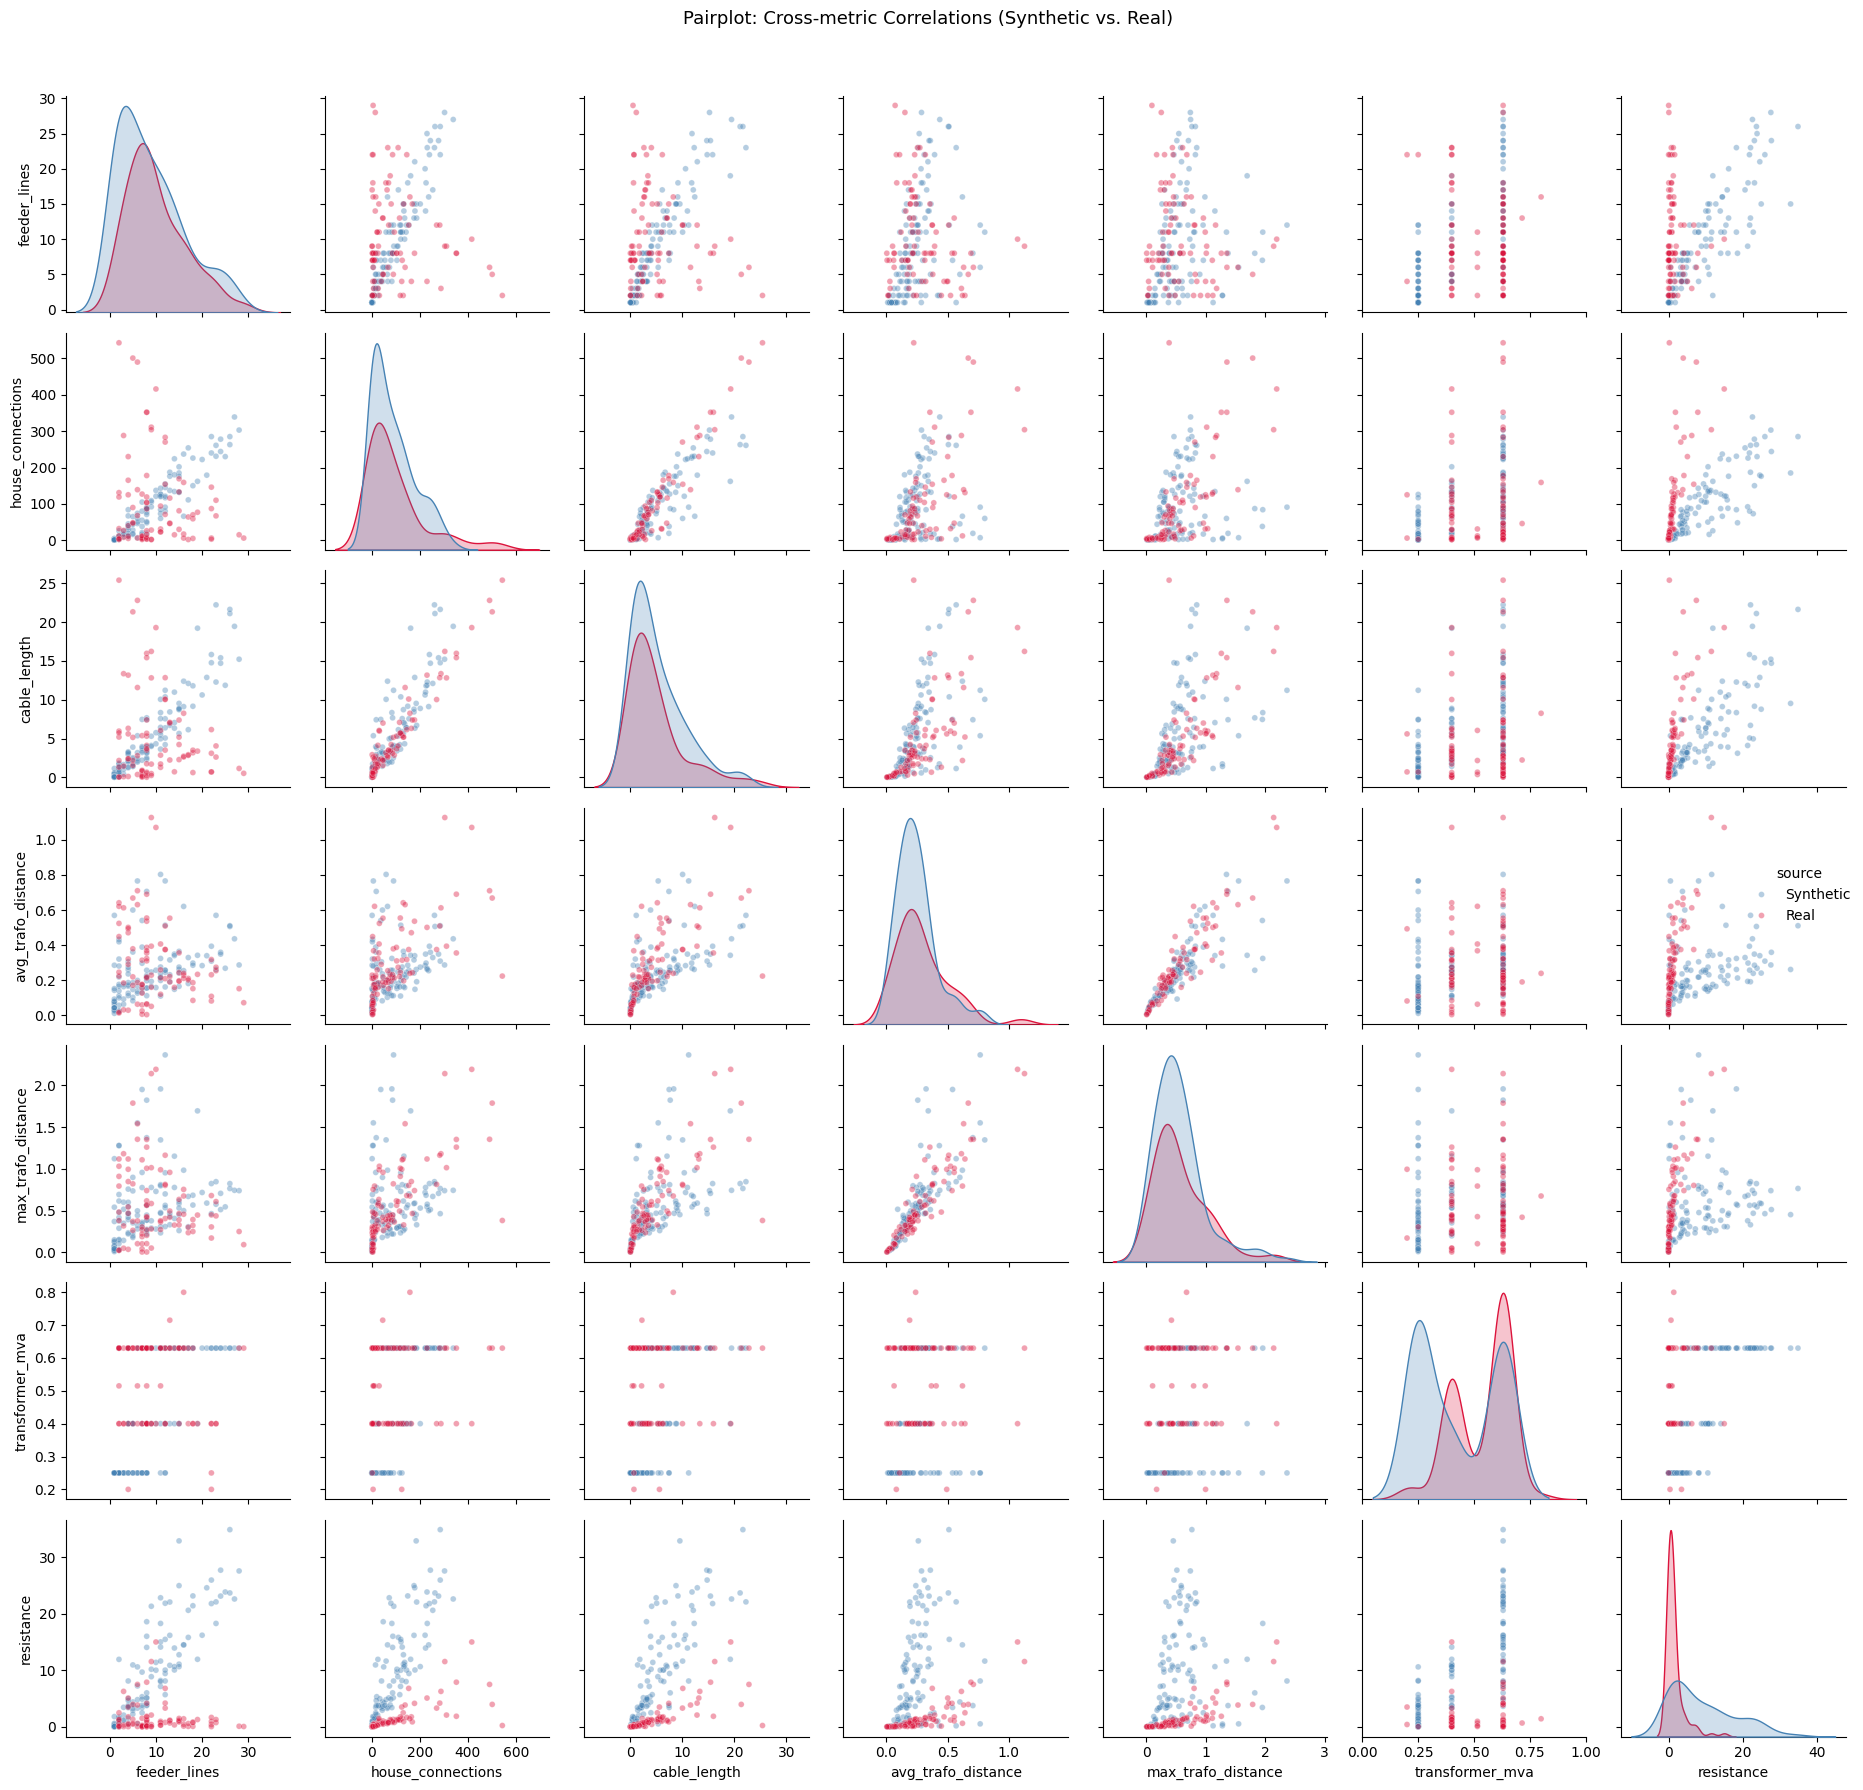

In [9]:
palette = {'Synthetic': 'steelblue', 'Real': 'crimson'}

g = sns.pairplot(
    df_all[metrics + ['source']].dropna(),
    hue='source',
    palette=palette,
    plot_kws={'alpha': 0.4, 's': 18},
    diag_kind='kde',
)
g.fig.suptitle(
    "Pairplot: Cross-metric Correlations (Synthetic vs. Real)",
    y=1.02,
    fontsize=13,
)
plt.tight_layout()
plt.show()


## 5. Geospatial Comparison

Visualise individual grid topologies on an **interactive OpenStreetMap** background. This goes beyond aggregate metrics and lets you inspect how a grid is *shaped* in geographic space — feeder routing, coverage area, transformer position.

**Requirements:**
- **Real grids (5a):** Set `REAL_GRID_DIR` in Section 0 to the folder containing your `LV_*.json` files. These are standard pandapower JSON exports. Their bus coordinates are stored as GeoJSON strings in `net.bus['geo']`; the helper below converts them automatically to `bus_geodata` before plotting.
- **Synthetic grids (5b):** Requires a running database connection (configured via pylovo's `config.yaml`).

Both sections use `pandapower.plotting.plotly.simple_plotly(net, on_map=True, map_style="open-street-map")` — no Mapbox token required.


In [10]:
import json as _json
import pyproj as _pyproj
import plotly.graph_objects as go


def _convert_net_geo_to_wgs84(net, source_crs: str = "epsg:25832"):
    """
    Convert net.bus.geo and net.line.geo GeoJSON coordinates from a projected CRS to WGS84 in-place.

    Real LV nets exported from GIS tools (e.g. Forchheim data) store coordinates in
    EPSG:25832 (UTM Zone 32N). pandapower's simple_plotly reads net.bus.geo / net.line.geo
    directly and requires WGS84 lon/lat for map rendering.
    """
    transformer = _pyproj.Transformer.from_crs(source_crs, "epsg:4326", always_xy=True)

    def _convert_point(geo_str):
        if not isinstance(geo_str, str):
            return geo_str
        try:
            g = _json.loads(geo_str)
            if g.get("type") == "Point":
                lon, lat = transformer.transform(*g["coordinates"])
                return _json.dumps({"type": "Point", "coordinates": [lon, lat]})
        except Exception:
            pass
        return geo_str

    def _convert_linestring(geo_str):
        if not isinstance(geo_str, str):
            return geo_str
        try:
            g = _json.loads(geo_str)
            if g.get("type") == "LineString":
                new_coords = [list(transformer.transform(x, y)) for x, y in g["coordinates"]]
                return _json.dumps({"type": "LineString", "coordinates": new_coords})
        except Exception:
            pass
        return geo_str

    net.bus["geo"] = net.bus["geo"].apply(_convert_point)
    if "geo" in net.line.columns:
        net.line["geo"] = net.line["geo"].apply(_convert_linestring)


def _needs_projection(net) -> bool:
    """Return True if bus.geo coordinates are in a projected CRS (not WGS84 lon/lat)."""
    sample = net.bus["geo"].dropna()
    if sample.empty:
        return False
    try:
        coords = _json.loads(sample.iloc[0]).get("coordinates", [0, 0])
        return abs(coords[0]) > 180 or abs(coords[1]) > 90
    except Exception:
        return False


def load_real_net_for_plotting(file_name: str):
    """
    Load a real LV grid from JSON and ensure bus.geo / line.geo are in WGS84.

    Real grid exports (e.g. from Forchheim GIS) store coordinates in EPSG:25832.
    This function auto-detects and converts in-place so simple_plotly works correctly.
    """
    if REAL_GRID_DIR is None:
        print("REAL_GRID_DIR is not configured. Set it in Section 0.")
        return None

    json_path = Path(REAL_GRID_DIR) / file_name
    if not json_path.exists():
        print(f"File not found: {json_path}")
        return None

    net = pp.from_json(str(json_path))

    if _needs_projection(net):
        _convert_net_geo_to_wgs84(net, source_crs="epsg:25832")

    return net


def _net_to_map_traces(net, line_color="grey", bus_color="blue", name_prefix=""):
    """
    Convert a pandapower net to Scattermap traces (lon/lat) for map overlay.

    Uses simple_plotly with auto_draw_traces=False to get raw x/y traces, then
    converts them to Scattermap without triggering pandapower's internal iplot call.
    """
    import pandapower.plotting.plotly as _pp_plotly

    traces, _ = _pp_plotly.simple_plotly(
        net, on_map=True, map_style="open-street-map", auto_draw_traces=False
    )

    map_traces = []
    for trace in traces:
        lon = list(trace.get("x") or [])
        lat = list(trace.get("y") or [])
        if not lon or not lat:
            continue

        # Extract line / marker props as plain dicts to avoid go.scatter.Line type mismatch
        line_props = {}
        if "line" in trace and trace["line"] is not None:
            try:
                raw = trace["line"]._props if hasattr(trace["line"], "_props") else dict(trace["line"])
                line_props = {k: v for k, v in raw.items() if k != "dash"}  # dash unsupported in Scattermap
            except Exception:
                pass

        marker_props = {}
        if "marker" in trace and trace["marker"] is not None:
            try:
                marker_props = dict(trace["marker"]._props) if hasattr(trace["marker"], "_props") else dict(trace["marker"])
            except Exception:
                pass

        map_traces.append(go.Scattermap(
            lon=lon,
            lat=lat,
            mode=trace.get("mode", "markers"),
            name=f"{name_prefix}{trace.get('name', '')}",
            text=trace.get("text", ""),
            hoverinfo=trace.get("hoverinfo", "text"),
            showlegend=trace.get("showlegend", True),
            legendgroup=f"{name_prefix}{trace.get('legendgroup', '')}",
            line=line_props if line_props else None,
            marker=marker_props if marker_props else None,
        ))

    return map_traces


def _get_geo_bbox(net):
    """Return (lon_min, lat_min, lon_max, lat_max) from net.bus.geo (WGS84)."""
    lons, lats = [], []
    for geo_str in net.bus["geo"].dropna():
        try:
            coords = _json.loads(geo_str)["coordinates"]
            lons.append(coords[0])
            lats.append(coords[1])
        except Exception:
            pass
    if not lons:
        return None
    return min(lons), min(lats), max(lons), max(lats)


def _bboxes_intersect(a, b):
    """Check if two (lon_min, lat_min, lon_max, lat_max) bounding boxes overlap."""
    return not (a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1])


# Module-level transformer for EPSG:25832 → WGS84 (re-used by helpers to avoid per-call overhead)
_UTM32_TO_WGS84 = _pyproj.Transformer.from_crs("epsg:25832", "epsg:4326", always_xy=True)


def _get_bbox_fast(file_path: str):
    """
    Return (lon_min, lat_min, lon_max, lat_max) from a real-grid JSON file without
    loading the full pandapower network.  ~100x faster than pp.from_json for scanning.
    Coordinates in EPSG:25832 are auto-converted to WGS84.
    """
    try:
        with open(file_path) as _f:
            _data = _json.load(_f)
        _bus_raw = _data["_object"]["bus"]["_object"]
        _bus_obj = _json.loads(_bus_raw) if isinstance(_bus_raw, str) else _bus_raw
        _cols = _bus_obj["columns"]
        _rows = _bus_obj["data"]
        _gi   = _cols.index("geo")
        _lons, _lats = [], []
        for _row in _rows:
            _v = _row[_gi]
            if not isinstance(_v, str):
                continue
            _g = _json.loads(_v)
            _x, _y = _g["coordinates"]
            if abs(_x) > 180:
                _lon, _lat = _UTM32_TO_WGS84.transform(_x, _y)
            else:
                _lon, _lat = _x, _y
            _lons.append(_lon)
            _lats.append(_lat)
        if _lons:
            return min(_lons), min(_lats), max(_lons), max(_lats)
    except Exception:
        pass
    return None


### 5a. Real Grid Map

Select a real grid by name. The network topology (buses and lines) is drawn on an OpenStreetMap background. Bus markers show transformer and consumer buses; line traces show the cable routing.

> Requires `REAL_GRID_DIR` to be set in Section 0.


In [11]:
if not df_real.empty and 'file_name' in df_real.columns:
    real_grid_map = dict(
        df_real[['grid_name', 'file_name']].dropna().itertuples(index=False, name=None)
    )

    def plot_real_grid(grid_name):
        net = load_real_net_for_plotting(real_grid_map[grid_name])
        if net is None or net.bus["geo"].dropna().empty:
            print("No geographic data found in this grid.")
            return

        traces = _net_to_map_traces(net)
        bbox = _get_geo_bbox(net)
        center_lon = (bbox[0] + bbox[2]) / 2 if bbox else 0
        center_lat = (bbox[1] + bbox[3]) / 2 if bbox else 0

        fig = go.Figure(data=traces)
        fig.update_layout(
            title_text=f"Real Grid: {grid_name}",
            height=640,
            showlegend=True,
            margin=dict(l=5, r=5, b=5, t=40),
            map=dict(style="open-street-map", zoom=14, center=dict(lon=center_lon, lat=center_lat)),
        )
        fig.show()

    interact(
        plot_real_grid,
        grid_name=widgets.Dropdown(
            options=list(real_grid_map.keys()),
            description="Grid:",
            layout=widgets.Layout(width='300px'),
        ),
    )
else:
    print("No real grid data available. Ensure real_grid_metrics.csv is loaded and REAL_GRID_DIR is set.")


interactive(children=(Dropdown(description='Grid:', layout=Layout(width='300px'), options=('LV_028', 'LV_029',…

### 5b. Synthetic Grid Map with Real Grid Overlay

Enter the `plz`, `kcid`, and `bcid` of any generated grid. The synthetic network is plotted in **blue/grey/green** (buses / lines / transformer). Any real grids whose geographic bounding box **intersects** the synthetic grid's extent are automatically overlaid in **red** on the same map.

> Requires a database connection. If `REAL_GRID_DIR` is also set, overlapping real grids are loaded and overlaid automatically.


In [12]:
# ── 5b State ────────────────────────────────────────────────────────────────
_5b_state = {}  # persistent between the two widget steps

# ── Widgets ──────────────────────────────────────────────────────────────────
_plz_w   = widgets.IntText(value=91301, description="PLZ:",
                            layout=widgets.Layout(width="200px"))
_kcid_w  = widgets.IntText(value=0,     description="KCID:",
                            layout=widgets.Layout(width="200px"))
_bcid_w  = widgets.IntText(value=0,     description="BCID:",
                            layout=widgets.Layout(width="200px"))

_find_btn  = widgets.Button(
    description="1. Find Intersecting Grids",
    button_style="primary",
    layout=widgets.Layout(width="240px"),
)
_step1_out = widgets.Output()

_real_dd  = widgets.Dropdown(
    description="Real grid:", options=[],
    layout=widgets.Layout(width="340px"),
)
_plot_btn = widgets.Button(
    description="2. Plot Overlay",
    button_style="success",
    layout=widgets.Layout(width="160px"),
)
_step2_out = widgets.Output()
_step2_box = widgets.VBox([widgets.HBox([_real_dd, _plot_btn]), _step2_out])
_step2_box.layout.display = "none"  # hidden until step 1 succeeds


# ── Step 1: load synthetic grid and scan real grids for bbox overlap ─────────
def _5b_find_click(_):
    _step1_out.clear_output()
    _step2_box.layout.display = "none"
    _step2_out.clear_output()
    with _step1_out:
        plz, kcid, bcid = _plz_w.value, _kcid_w.value, _bcid_w.value
        print(f"Loading synthetic grid  PLZ={plz}  KCID={kcid}  BCID={bcid} …")
        try:
            with DatabaseClient() as dbc:
                net_synth = dbc.read_net_db(int(plz), int(kcid), int(bcid))
        except Exception as exc:
            print(f"Could not load synthetic grid: {exc}")
            return

        synth_bbox = _get_geo_bbox(net_synth)
        _5b_state.update(net_synth=net_synth, synth_bbox=synth_bbox,
                         plz=plz, kcid=kcid, bcid=bcid)

        if (
            REAL_GRID_DIR is None
            or df_real.empty
            or "file_name" not in df_real.columns
            or synth_bbox is None
        ):
            print("REAL_GRID_DIR not configured or no real grid data — showing synthetic only.")
            _5b_plot(selected_real=None)
            return

        print("Scanning real grids for bounding-box intersection …")
        intersecting = []
        for _, row in df_real[["grid_name", "file_name"]].dropna().iterrows():
            fp = Path(REAL_GRID_DIR) / row["file_name"]
            if not fp.exists():
                continue
            real_bbox = _get_bbox_fast(str(fp))
            if real_bbox and _bboxes_intersect(synth_bbox, real_bbox):
                intersecting.append((row["grid_name"], row["file_name"]))

        if not intersecting:
            print("No intersecting real grids found — showing synthetic only.")
            _5b_plot(selected_real=None)
            return

        _5b_state["fname_lookup"] = {name: fname for name, fname in intersecting}
        _real_dd.options = [name for name, _ in intersecting]

        n = len(intersecting)
        print(f"Found {n} intersecting real grid(s).  "
              f"Select one and click '2. Plot Overlay'.")
    _step2_box.layout.display = ""


_find_btn.on_click(_5b_find_click)


# ── Step 2: render synthetic + one selected real grid ────────────────────────
def _5b_plot(selected_real):
    net_synth  = _5b_state.get("net_synth")
    synth_bbox = _5b_state.get("synth_bbox")
    plz  = _5b_state.get("plz",  "?")
    kcid = _5b_state.get("kcid", "?")
    bcid = _5b_state.get("bcid", "?")

    synth_traces = _net_to_map_traces(net_synth, name_prefix="Synthetic: ")
    all_traces   = list(synth_traces)

    if selected_real is not None:
        fname    = _5b_state.get("fname_lookup", {}).get(selected_real, selected_real)
        net_real = load_real_net_for_plotting(fname)
        if net_real is not None:
            real_traces = _net_to_map_traces(
                net_real, name_prefix=f"Real {selected_real}: "
            )
            for t in real_traces:
                t.update(
                    line=dict(color="crimson"),
                    marker=dict(color="crimson"),
                )
            all_traces.extend(real_traces)

    if not all_traces:
        print("No plottable geo data found.")
        return

    center_lon = ((synth_bbox[0] + synth_bbox[2]) / 2) if synth_bbox else 0
    center_lat = ((synth_bbox[1] + synth_bbox[3]) / 2) if synth_bbox else 0

    fig = go.Figure(data=all_traces)
    fig.update_layout(
        title_text=f"Synthetic Grid — PLZ {plz}, KCID {kcid}, BCID {bcid}",
        height=660,
        showlegend=True,
        margin=dict(l=5, r=5, b=5, t=40),
        map=dict(
            style="open-street-map",
            zoom=14,
            center=dict(lon=center_lon, lat=center_lat),
        ),
    )
    fig.show()


def _5b_plot_click(_):
    with _step2_out:
        _step2_out.clear_output()
        selected_real = _real_dd.value
        if selected_real:
            print(f"Loading real grid '{selected_real}' …")
            _5b_plot(selected_real)


_plot_btn.on_click(_5b_plot_click)

# ── Layout ───────────────────────────────────────────────────────────────────
display(
    widgets.VBox([
        widgets.HTML(
            "<b>Synthetic Grid — Real Grid Overlay</b><br>"
            "<small><b>Step 1:</b> Enter the grid coordinates and click "
            "<i>Find Intersecting Grids</i>.<br>"
            "<b>Step 2:</b> Pick one matching real grid and click "
            "<i>Plot Overlay</i>.</small>"
        ),
        widgets.HBox([_plz_w, _kcid_w, _bcid_w]),
        _find_btn,
        _step1_out,
        _step2_box,
    ])
)


### 5c. Geographic Coverage Overview

Static overview map showing where **synthetic grids** (transformer locations, left) and **real grids** (grid centroids, right) are located.  Both datasets cover the same area around Forchheim, Bavaria — this plot confirms their geographic overlap before deeper comparisons.

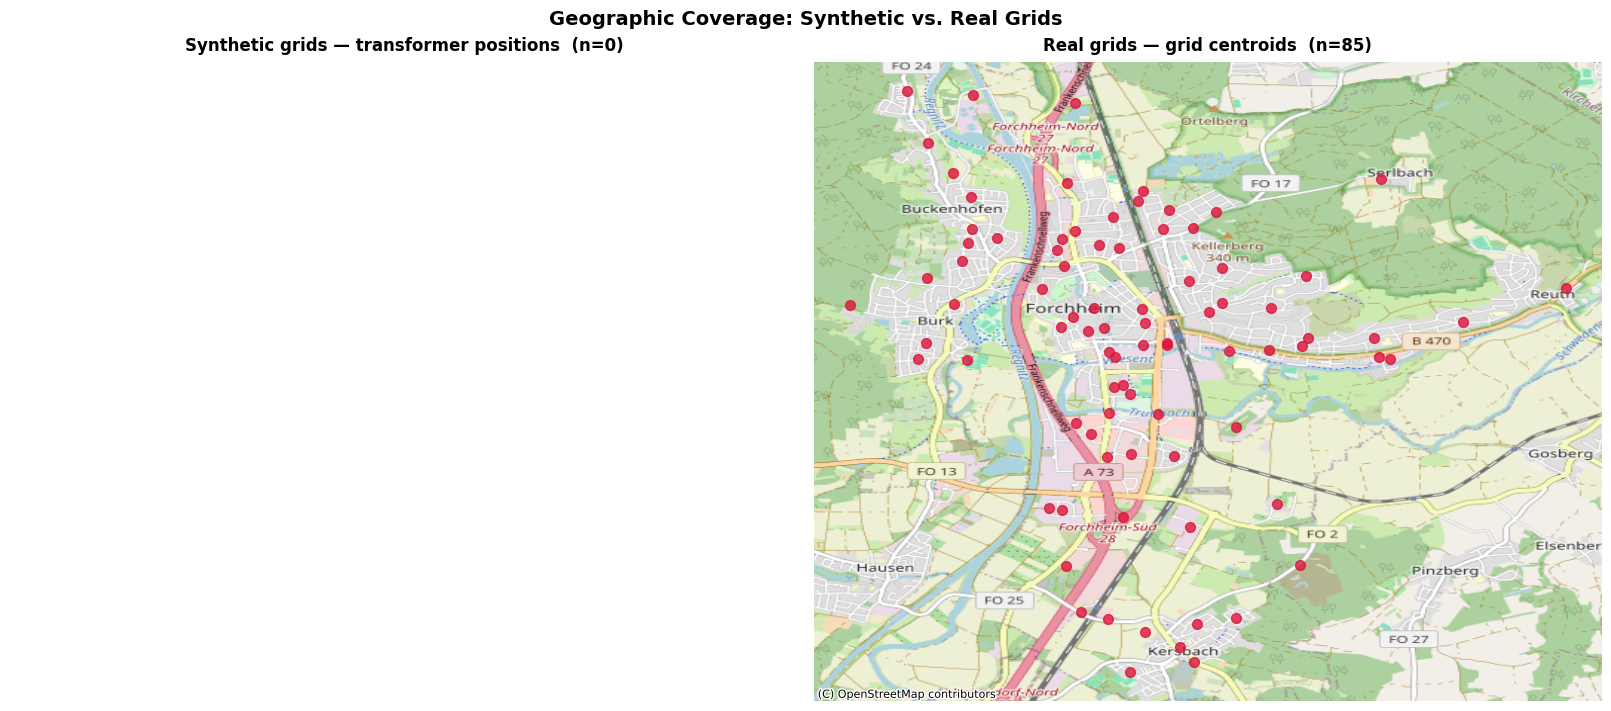

In [13]:
import contextily as cx

# ── Synthetic grid positions — transformer coordinates from DB ────────────────
_synth_ids = df_synth["grid_result_id"].dropna().astype(int).unique().tolist()
with DatabaseClient() as dbc:
    _q_synth = f"""
        SELECT grid_result_id,
               ST_X(ST_Transform(geom, 4326)) AS lon,
               ST_Y(ST_Transform(geom, 4326)) AS lat
        FROM transformer_positions
        WHERE grid_result_id = ANY(ARRAY{_synth_ids})
    """
    df_synth_geo = pd.read_sql(_q_synth, dbc.sqla_engine)

# ── Real grid positions — centroids from JSON files (fast, no pp.from_json) ──
_real_centroids = []
if REAL_GRID_DIR is not None and not df_real.empty and "file_name" in df_real.columns:
    for _, _row in df_real[["grid_name", "file_name"]].dropna().iterrows():
        _fp = Path(REAL_GRID_DIR) / _row["file_name"]
        if _fp.exists():
            _bb = _get_bbox_fast(str(_fp))
            if _bb:
                _real_centroids.append({
                    "grid_name": _row["grid_name"],
                    "lon": (_bb[0] + _bb[2]) / 2,
                    "lat": (_bb[1] + _bb[3]) / 2,
                })
df_real_geo = pd.DataFrame(_real_centroids)

# ── WGS84 → Web Mercator (EPSG:3857) for contextily ─────────────────────────
_to_web = _pyproj.Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

# Left — synthetic transformer positions
ax = axes[0]
if not df_synth_geo.empty:
    _sx, _sy = _to_web.transform(
        df_synth_geo["lon"].values, df_synth_geo["lat"].values
    )
    ax.scatter(_sx, _sy, c="steelblue", s=50, alpha=0.8, zorder=3)
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title(
    f"Synthetic grids — transformer positions  (n={len(df_synth_geo)})",
    fontsize=12, fontweight="bold", pad=8,
)
ax.set_axis_off()

# Right — real grid centroids
ax = axes[1]
if not df_real_geo.empty:
    _rx, _ry = _to_web.transform(
        df_real_geo["lon"].values, df_real_geo["lat"].values
    )
    ax.scatter(_rx, _ry, c="crimson", s=50, alpha=0.8, zorder=3)
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title(
    f"Real grids — grid centroids  (n={len(df_real_geo)})",
    fontsize=12, fontweight="bold", pad=8,
)
ax.set_axis_off()

fig.suptitle(
    "Geographic Coverage: Synthetic vs. Real Grids",
    fontsize=14, fontweight="bold",
)
plt.show()
